<a href="https://colab.research.google.com/github/heisenberg304/Housing-Prices-prediction/blob/develop/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%writefile data_housing.py
import pandas as pd

#cargar datos
data_original = pd.read_csv("/content/drive/MyDrive/data_csv/House_Prices_train.csv")


Writing data_housing.py


# Objetivo del proyecto

El objetivo de este proyecto es desarrollar un modelo capaz de predecir el precio de venta de una vivienda utilizando las características de la propiedad disponibles en el dataset.

**Variable objetivo:** SalePrice

# Hipótesis iniciales

Antes de realizar el análisis exploratorio de datos, se plantean las siguientes hipótesis:

1. Las viviendas con una mayor superficie habitable tenderán a tener precios de venta más elevados.

2. El vecindario o ubicación de la vivienda tendrá una influencia significativa sobre el precio final, ya que algunas zonas suelen ser más demandadas que otras.

3. Determinadas características adicionales, como piscina, aire acondicionado, garaje o espacios recreativos, podrían incrementar el valor de la propiedad, especialmente en contextos donde estas características sean altamente valoradas.

4. Las viviendas más modernas o construidas recientemente tenderán a presentar precios más altos debido a mejoras estructurales, mayor eficiencia y una mejor adaptación a las necesidades actuales.

5. La calidad general de la construcción y de los acabados de la vivienda será uno de los factores más importantes para determinar su precio de venta.

Estas hipótesis serán contrastadas durante el análisis exploratorio de datos (EDA) para determinar cuáles están respaldadas por la evidencia disponible en el dataset.



# Dataset Overview

El dataset utilizado para este proyecto contiene **1460 observaciones** y **81 variables**, incluyendo la variable objetivo (SalePrice).

Tras una primera inspección, se identifican las siguientes características:

* El dataset presenta una ligera predominancia de variables categóricas, con un total de **43 variables** de tipo object.
* También cuenta con una cantidad considerable de variables numéricas, **38 en total**, distribuidas en 35 variables enteras (int) y 3 variables de punto flotante (float).
* La combinación de variables numéricas y categóricas sugiere que será necesario aplicar diferentes estrategias de preprocesamiento antes del modelado.
* En esta etapa aún no se ha verificado si algunas variables numéricas representan en realidad categorías codificadas mediante números. Este análisis se realizará durante el EDA para determinar el tratamiento más adecuado para cada variable.

Esta primera revisión proporciona una visión general de la estructura del dataset y servirá como punto de partida para el análisis exploratorio de datos.


In [ ]:
from data_housing import data_original
import pandas as pd


data = data_original.copy()

data.shape #(1460, 81)
data.head()
data.info() #dtypes: float64(3), int64(35), object(43)
data.describe()

# Missing Values Analysis

El análisis inicial de valores faltantes muestra que algunas variables presentan una cantidad considerable de datos ausentes.

### Variables con mayor cantidad de valores faltantes

* PoolQC: 1453
* MiscFeature: 1406
* Alley: 1369
* Fence: 1179

La elevada cantidad de valores faltantes en estas variables sugiere que los NaN podrían no representar datos perdidos, sino la ausencia de la característica correspondiente. Por ejemplo, una vivienda que no posee piscina probablemente no tendrá información registrada en PoolQC.

### Variables relacionadas con el garaje

Las siguientes variables presentan exactamente **81 valores faltantes**:

* GarageQual
* GarageYrBlt
* GarageFinish
* GarageType
* GarageCond

El hecho de que todas compartan la misma cantidad de valores faltantes sugiere que estos registros podrían estar relacionados entre sí. Una posible hipótesis es que las viviendas afectadas no dispongan de garaje, provocando la ausencia simultánea de información en todas estas variables. Esta hipótesis deberá verificarse durante el análisis posterior.

### Variables relacionadas con el sótano

Las siguientes variables también presentan una cantidad muy similar de valores faltantes:

* BsmtFinType1: 37
* BsmtQual: 37
* BsmtCond: 37
* BsmtFinType2: 38
* BsmtExposure: 38

Al igual que ocurre con las variables del garaje, la similitud en el número de valores faltantes sugiere una relación entre ellas. Sin embargo, se observa una diferencia de un registro adicional en `BsmtFinType2` y `BsmtExposure`, lo que podría indicar la existencia de casos especiales o inconsistencias en los datos que deberán investigarse con mayor detalle.

### Hipótesis iniciales

A partir de estas observaciones se plantean las siguientes hipótesis:

1. Una parte importante de los valores faltantes representa la ausencia real de determinadas características de la vivienda y no errores de registro.
2. Los grupos de variables relacionadas con garajes y sótanos presentan dependencias entre sí, por lo que su tratamiento deberá realizarse de forma conjunta.
3. Existen algunos casos particulares que requerirán una inspección individual antes de decidir la estrategia de imputación.


In [ ]:
from data_housing import data_original
import pandas as pd


data = data_original.copy()

missing = data.isnull().sum().sort_values()
missing[missing > 0]

# Target Variable Analysis

## Transformación aplicada

Se aplicó una transformación logarítmica mediante `log1p()` sobre la variable objetivo `SalePrice`.

El objetivo de esta transformación fue reducir la asimetría positiva de la distribución y disminuir el impacto de los valores extremadamente altos sobre el modelo.

## Comparación antes y después de la transformación

Antes de la transformación, `SalePrice` presenta una distribución claramente sesgada hacia la derecha. La mayoría de las viviendas se concentra en rangos de precios bajos y medios, mientras que existe un grupo reducido de propiedades con precios considerablemente más altos.

Después de aplicar `log1p()`, la distribución se vuelve más simétrica y cercana a una distribución normal. Esto facilita el modelado y puede mejorar el rendimiento de algoritmos sensibles a la escala y distribución de los datos.

## Análisis de outliers

Los diagramas de caja muestran la presencia de múltiples valores atípicos en la parte superior de la distribución.

Tras la transformación logarítmica, estos valores atípicos continúan existiendo, pero su impacto relativo disminuye debido a la compresión de la escala producida por el logaritmo.

## Conclusiones

* `SalePrice` presenta una marcada asimetría positiva.
* Existen múltiples propiedades con precios significativamente superiores al resto del conjunto de datos.
* La transformación logarítmica reduce la asimetría y produce una distribución más equilibrada.
* La mediana representa mejor el comportamiento típico de los precios que la media, ya que esta última se ve influenciada por los valores extremos.
* La variable transformada parece ser una mejor candidata para las etapas posteriores de modelado.


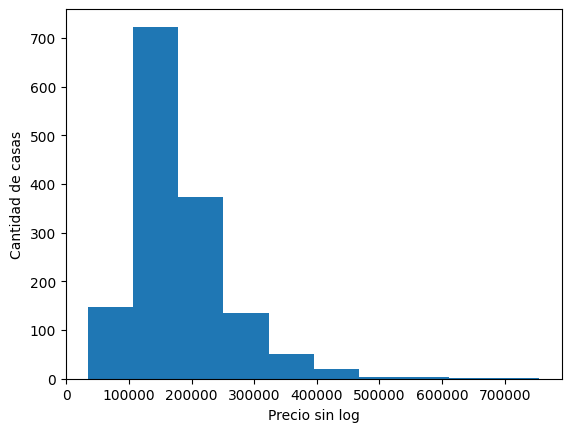

---

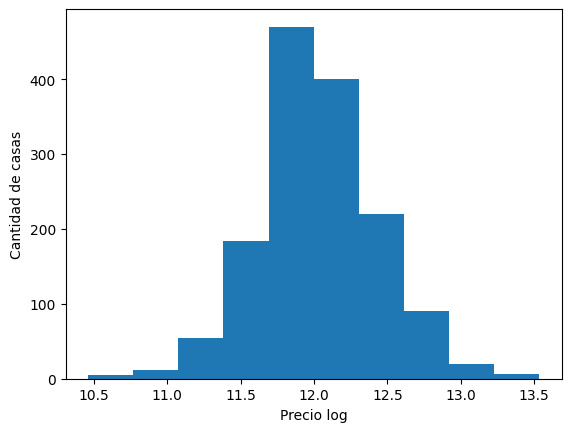

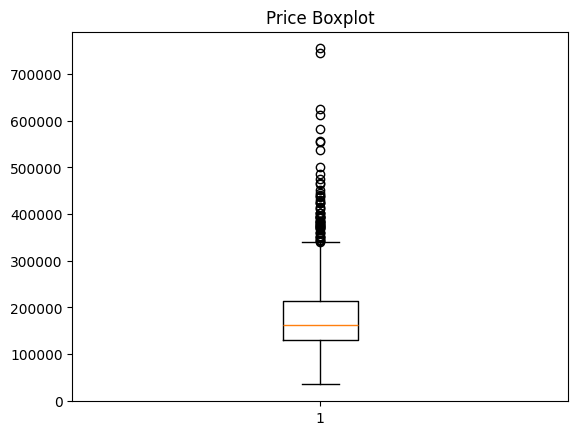

---

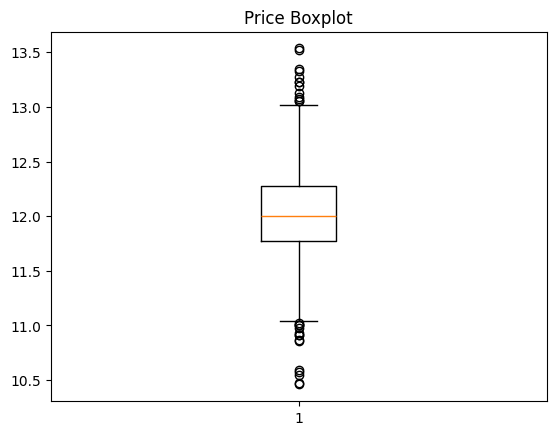

In [ ]:
from data_housing import data_original
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


data = data_original.copy()
price = data['SalePrice']

plt.hist(price)
plt.ylabel("Cantidad de casas")
plt.xlabel("Precio sin log")
plt.show()

plt.hist(np.log1p(price)) #np.expm1(price) para descomprimir
plt.ylabel("Cantidad de casas")
plt.xlabel("Precio log")
plt.show()

plt.boxplot(price)
plt.title("Price Boxplot")
plt.show()

plt.boxplot(np.log1p(price))
plt.title("Price Boxplot")
plt.show()


# Correlation Analysis

Con el objetivo de identificar las variables numéricas más relacionadas con el precio de venta (`SalePrice`), se calculó el coeficiente de correlación de Pearson entre la variable objetivo y el resto de variables numéricas del dataset.

## Variables con mayor correlación positiva con `SalePrice`

| Variable     | Correlación |
| ------------ | ----------- |
| OverallQual  | 0.790982    |
| GrLivArea    | 0.708624    |
| GarageCars   | 0.640409    |
| GarageArea   | 0.623431    |
| TotalBsmtSF  | 0.613581    |
| 1stFlrSF     | 0.605852    |
| FullBath     | 0.560664    |
| TotRmsAbvGrd | 0.533723    |
| YearBuilt    | 0.522897    |
| YearRemodAdd | 0.507101    |

### Observaciones

La variable **OverallQual** presenta la correlación positiva más alta con `SalePrice` (0.79), lo que sugiere que la calidad general de la vivienda es uno de los factores más importantes para determinar su valor de mercado.

Asimismo, variables relacionadas con el tamaño de la vivienda, como **GrLivArea**, **TotalBsmtSF** y **1stFlrSF**, muestran correlaciones elevadas, respaldando la hipótesis inicial de que las propiedades con mayor superficie habitable tienden a alcanzar precios más altos.

Las variables asociadas al garaje (**GarageCars** y **GarageArea**) también presentan una relación importante con el precio, lo que indica que la capacidad y el tamaño del garaje son características valoradas por los compradores.

Finalmente, **YearBuilt** y **YearRemodAdd** muestran correlaciones positivas moderadas, sugiriendo que las viviendas más recientes o remodeladas suelen tener un mayor valor de mercado.

## Variables con mayor correlación negativa con `SalePrice`

| Variable      | Correlación |
| ------------- | ----------- |
| BsmtFinSF2    | -0.011378   |
| BsmtHalfBath  | -0.016844   |
| MiscVal       | -0.021190   |
| Id            | -0.021917   |
| LowQualFinSF  | -0.025606   |
| YrSold        | -0.028923   |
| OverallCond   | -0.077856   |
| MSSubClass    | -0.084284   |
| EnclosedPorch | -0.128578   |
| KitchenAbvGr  | -0.135907   |

### Observaciones

Las correlaciones negativas observadas son relativamente débiles en comparación con las correlaciones positivas encontradas anteriormente.

La variable **KitchenAbvGr** presenta la correlación negativa más alta (-0.14), aunque su magnitud sigue siendo baja. Esto sugiere que la cantidad de cocinas por encima del nivel del suelo no constituye un factor determinante para el precio de venta dentro de este conjunto de datos.

De manera similar, variables como **EnclosedPorch**, **MSSubClass** y **OverallCond** muestran relaciones negativas moderadas, aunque será necesario analizarlas con mayor profundidad para comprender su comportamiento y determinar si existe algún patrón subyacente.

## Conclusiones preliminares

Las correlaciones obtenidas respaldan varias de las hipótesis planteadas al inicio del proyecto:

* La calidad general de la vivienda parece ser uno de los factores más influyentes sobre el precio.
* El tamaño de la propiedad mantiene una relación positiva significativa con el valor de venta.
* Las características relacionadas con el garaje tienen una influencia importante en el precio.
* La antigüedad y las remodelaciones de la vivienda parecen afectar positivamente su valor de mercado.

Estas variables serán priorizadas en los siguientes bloques del EDA para comprender mejor su comportamiento y su posible contribución al modelo de predicción.


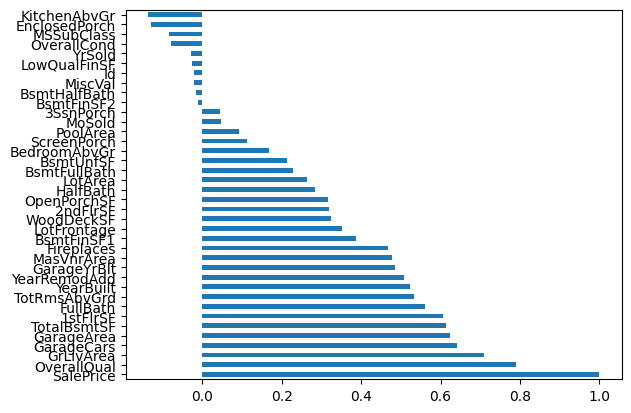

In [34]:
from data_housing import data_original
import matplotlib.pyplot as plt

data = data_original.copy()

target_corr = (data.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False))
#display(target_corr)

#target_corr.plot.barh()
#plt.show()

data['YearBuilt'].value_counts()

,count
YearBuilt,
2006,67
2005,64
2004,54
2007,49
2003,45
...,...
1875,1
1911,1
1917,1


#Numerical Features Analysis



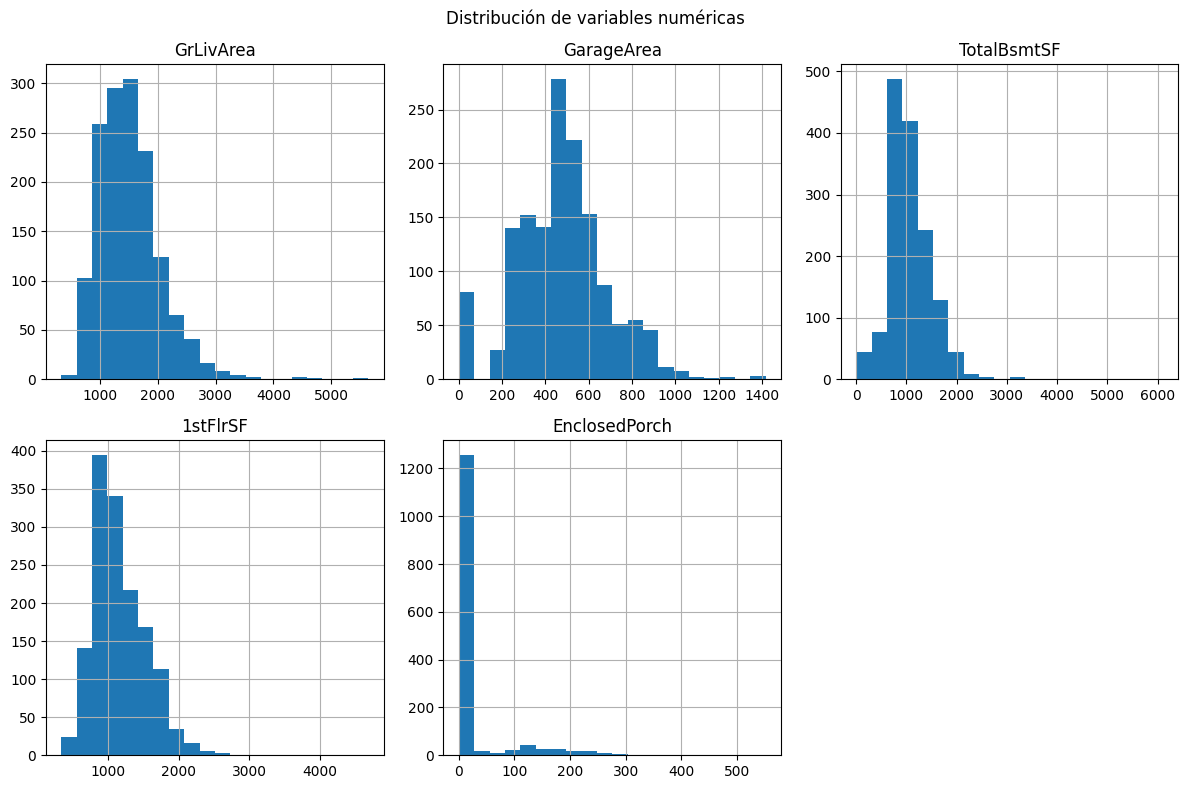

In [31]:
from data_housing import data_original
import pandas as pd
import matplotlib.pyplot as plt

data = data_original.copy()

features = ['GrLivArea','GarageArea', 'TotalBsmtSF', '1stFlrSF', 'EnclosedPorch']

data[features].hist(
    bins=20,
    figsize=(12,8),
    layout=(2,3)
)

#Cat: 'OverallQual', 'GarageCars', 'Neigbornhood', 'FullBath', 'KitchenAbvGr'

plt.suptitle('Distribución de variables numéricas')
plt.tight_layout()
plt.show()

#Categorical Features Analysis



In [ ]:
from data_housing import data_original
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = data_original.copy()

features = ['OverallQual', 'GarageCars', 'Neigbornhood', 'FullBath', 'KitchenAbvGr']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for feature, ax in zip(features, axes.flatten()):
    sns.scatterplot(
        data=data,
        x=feature,
        y='SalePrice',
        ax=ax
    )
    ax.set_title(f'{feature} vs SalePrice')

plt.tight_layout()
plt.show()

Outlier Analysis

Muy importante.

Gráficos:

boxplot

scatter

Especialmente:

GrLivArea vs SalePrice

In [ ]:
from data_housing import data_original
import pandas as pd


data = data_original.copy()

Initial Findings

Este bloque es oro.

Mucha gente no lo hace.

Ejemplo:

Hallazgo 1:
SalePrice presenta fuerte asimetría positiva.

Hallazgo 2:
OverallQual parece ser una de las variables más importantes.

Hallazgo 3:
Existen outliers en GrLivArea.

Hallazgo 4:
Múltiples NaN representan ausencia de características.

In [ ]:
from data_housing import data_original
import pandas as pd


data = data_original.copy()

Preprocessing Plan

RECIÉN AQUÍ.

No antes.

Escribes:

Plan de preprocesamiento:

1. Imputar LotFrontage por Neighborhood.

2. Convertir NaN de PoolQC a None.

3. Aplicar log1p a SalePrice.

4. One-Hot Encoding para variables categóricas.

5. Eliminar Id.